# Airline Delay Analysis

**Author:** Koloina Mioty Soa Razakahariseheno

This notebook explores operational patterns in aggregated U.S. airline-delay data. It combines exploratory data analysis with K-Means, hierarchical clustering, and PCA to identify recurring delay profiles among carrier-airport-month observations.

## Analysis scope

The analysis focuses on the 15 busiest airports during the available period from January 2022 to August 2023. Because 2023 is incomplete, direct year-to-year comparisons use only the common January-August period.

Clustering is used as an exploratory technique. The resulting groups describe operational profiles; they do not establish causal relationships.

## Import libraries

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

## Connect to Google Drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Load the dataset


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Unsupervised Machine Learning /FlightDelayData/Airline_Delay_Cause.csv')

In [ ]:
print(f"Original Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Original Dataset: 171666 rows, 21 columns


## Filter and validate the data

In [ ]:
# Select data from January 2022 to August 2023
analysis_years = [2022, 2023]
df_period = df.loc[df["year"].isin(analysis_years)].copy()

year_coverage = (
    df_period.groupby("year")["month"]
    .agg(first_month="min", last_month="max", number_of_months="nunique")
)

print("Data coverage by year:")
display(year_coverage)

# Identify the 15 busiest airports during the selected period
top_airport_codes = (
    df_period.groupby("airport")["arr_flights"]
    .sum()
    .nlargest(15)
    .index
)

df_filtered = (
    df_period.loc[df_period["airport"].isin(top_airport_codes)]
    .copy()
)

# Two records have a missing delayed-arrival count but zero total delay minutes.
# In these records, the missing count is interpreted as zero delayed arrivals.
missing_delay_mask = df_filtered["arr_del15"].isna()

if missing_delay_mask.any():
    missing_delay_rows = df_filtered.loc[
        missing_delay_mask,
        [
            "year", "month", "carrier", "carrier_name", "airport",
            "arr_flights", "arr_del15", "arr_cancelled", "arr_delay"
        ],
    ]
    print("Rows with missing delayed-arrival counts:")
    display(missing_delay_rows)

    if not df_filtered.loc[missing_delay_mask, "arr_delay"].eq(0).all():
        raise ValueError(
            "Some missing delayed-arrival counts have non-zero delay minutes. "
            "Inspect these records before imputing or continuing."
        )

    df_filtered.loc[missing_delay_mask, "arr_del15"] = 0.0

period_dates = pd.to_datetime(
    dict(
        year=df_filtered["year"],
        month=df_filtered["month"],
        day=1,
    )
)
analysis_period_label = (
    f"{period_dates.min():%B %Y} to {period_dates.max():%B %Y}"
)

print(f"\nFiltered dataset: {df_filtered.shape[0]:,} rows")
print(f"Analysis period: {analysis_period_label}")
print(f"Selected airports: {list(top_airport_codes)}")
print(f"Remaining missing values: {df_filtered.isna().sum().sum()}")
display(df_filtered.head())

Data coverage by year:


,first_month,last_month,number_of_months
year,,,
2022,1,12,12
2023,1,8,8


Rows with missing delayed-arrival counts:


,year,month,carrier,carrier_name,airport,arr_flights,arr_del15,arr_cancelled,arr_delay
32066,2022,1,OO,SkyWest Airlines Inc.,BOS,7.0,NaN,7.0,0.0
32552,2022,1,YV,Mesa Airlines Inc.,BOS,2.0,NaN,2.0,0.0



Filtered dataset: 3,384 rows
Analysis period: January 2022 to August 2023
Selected airports: ['ATL', 'DFW', 'DEN', 'ORD', 'LAX', 'CLT', 'LAS', 'SEA', 'PHX', 'LGA', 'MCO', 'DCA', 'BOS', 'JFK', 'EWR']
Remaining missing values: 0


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
5,2023,8,9E,Endeavor Air Inc.,ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",1636.0,256.0,55.98,27.81,...,0.0,108.57,32.0,11.0,29768.0,9339.0,4557.0,4676.0,0.0,11196.0
23,2023,8,9E,Endeavor Air Inc.,CLT,"Charlotte, NC: Charlotte Douglas International",232.0,38.0,9.94,1.00,...,0.0,13.60,9.0,1.0,2617.0,752.0,49.0,753.0,0.0,1063.0
30,2023,8,9E,Endeavor Air Inc.,DCA,"Washington, DC: Ronald Reagan Washington National",205.0,29.0,8.52,0.57,...,0.0,8.48,3.0,0.0,2886.0,749.0,46.0,1240.0,0.0,851.0
36,2023,8,9E,Endeavor Air Inc.,EWR,"Newark, NJ: Newark Liberty International",150.0,21.0,9.70,0.00,...,0.0,6.38,2.0,0.0,1264.0,620.0,0.0,237.0,0.0,407.0
50,2023,8,9E,Endeavor Air Inc.,JFK,"New York, NY: John F. Kennedy International",1576.0,213.0,49.85,13.99,...,0.1,72.82,32.0,0.0,21184.0,6213.0,2806.0,5420.0,5.0,6740.0


# Exploratory Data Analysis

## Summary statistics

In [ ]:
print(f"Dataset shape: {df_filtered.shape[0]:,} rows and {df_filtered.shape[1]} columns")
print(f"Duplicate rows: {df_filtered.duplicated().sum():,}")
print(f"Missing values: {df_filtered.isna().sum().sum():,}")

display(df_filtered.describe(include="all").T)

Dataset shape: 3,384 rows and 21 columns
Duplicate rows: 0
Missing values: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,3384.0,NaN,NaN,NaN,2022.380615,0.48561,2022.0,2022.0,2022.0,2023.0,2023.0
month,3384.0,NaN,NaN,NaN,5.695331,3.210742,1.0,3.0,5.0,8.0,12.0
carrier,3384,17,AA,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
carrier_name,3384,17,American Airlines Inc.,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airport,3384,15,BOS,272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airport_name,3384,16,"Boston, MA: Logan International",272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arr_flights,3384.0,NaN,NaN,NaN,1435.714539,2263.031744,1.0,150.0,658.5,1828.75,20084.0
arr_del15,3384.0,NaN,NaN,NaN,305.376478,456.528062,0.0,33.0,141.5,390.25,4142.0
carrier_ct,3384.0,NaN,NaN,NaN,98.308573,140.657145,0.0,12.8925,50.27,119.0,1293.91
weather_ct,3384.0,NaN,NaN,NaN,11.082459,21.799047,0.0,0.72,3.63,11.9325,266.42


In [ ]:
total_flights = df_filtered["arr_flights"].sum()
total_delayed = df_filtered["arr_del15"].sum()
total_cancelled = df_filtered["arr_cancelled"].sum()

overall_delay_rate = total_delayed / total_flights * 100
overall_cancellation_rate = total_cancelled / total_flights * 100
average_delay_minutes = df_filtered["arr_delay"].sum() / total_flights

print(f"Covered period: {analysis_period_label}")
print(f"Number of carriers: {df_filtered['carrier'].nunique()}")
print(f"Number of airports: {df_filtered['airport'].nunique()}")
print(f"Total arriving flights: {total_flights:,.0f}")
print(f"Average flights per carrier-airport-month record: {df_filtered['arr_flights'].mean():,.0f}")
print(f"Flights delayed by at least 15 minutes: {total_delayed:,.0f}")
print(f"Overall delay rate: {overall_delay_rate:.2f}%")
print(f"Overall cancellation rate: {overall_cancellation_rate:.2f}%")
print(f"Average delay minutes per scheduled flight: {average_delay_minutes:.2f}")

Covered period: January 2022 to August 2023
Number of carriers: 17
Number of airports: 15
Total arriving flights: 4,858,458
Average flights per carrier-airport-month record: 1,436
Flights delayed by at least 15 minutes: 1,033,394
Overall delay rate: 21.27%
Overall cancellation rate: 2.44%
Average delay minutes per scheduled flight: 15.79


## Distribution of delays

The distributions below are calculated for carrier-airport-month records. They show how operational volume and delay intensity vary across observations.

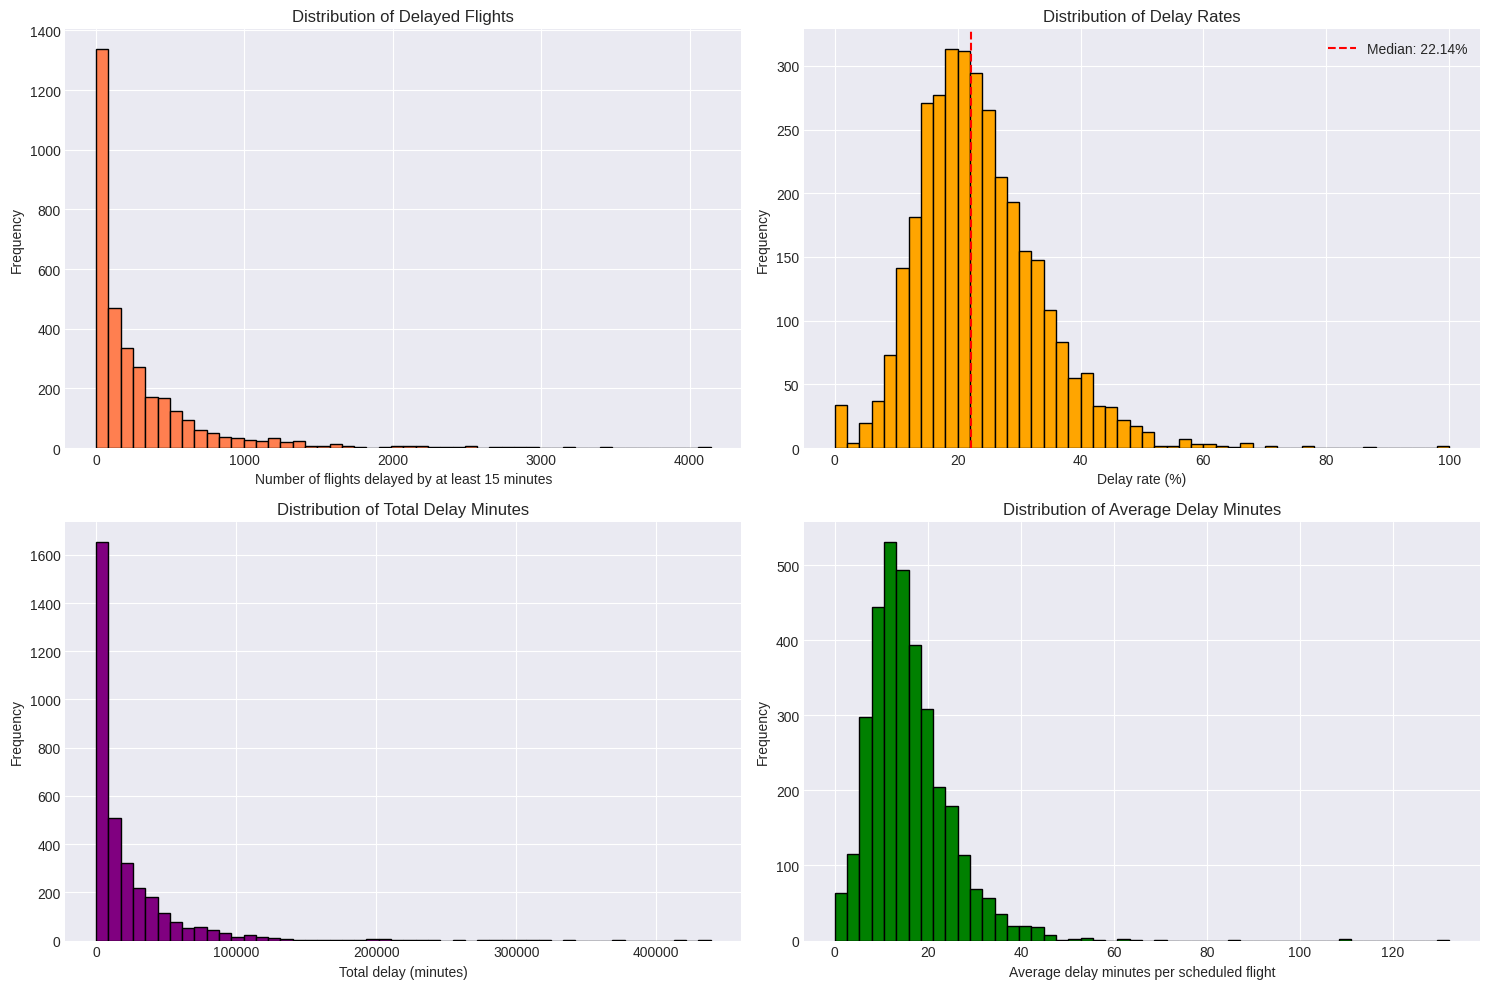

In [ ]:
eda_metrics = df_filtered.copy()
safe_flights = eda_metrics["arr_flights"].replace(0, np.nan)

eda_metrics["delay_rate"] = eda_metrics["arr_del15"] / safe_flights * 100
eda_metrics["cancellation_rate"] = eda_metrics["arr_cancelled"] / safe_flights * 100
eda_metrics["average_delay_minutes"] = eda_metrics["arr_delay"] / safe_flights

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(eda_metrics["arr_del15"], bins=50, edgecolor="black", color="coral")
axes[0, 0].set_xlabel("Number of flights delayed by at least 15 minutes")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Distribution of Delayed Flights")

axes[0, 1].hist(eda_metrics["delay_rate"].dropna(), bins=50, edgecolor="black", color="orange")
median_delay_rate = eda_metrics["delay_rate"].median()
axes[0, 1].axvline(
    median_delay_rate,
    color="red",
    linestyle="--",
    label=f"Median: {median_delay_rate:.2f}%",
)
axes[0, 1].set_xlabel("Delay rate (%)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Distribution of Delay Rates")
axes[0, 1].legend()

axes[1, 0].hist(eda_metrics["arr_delay"], bins=50, edgecolor="black", color="purple")
axes[1, 0].set_xlabel("Total delay (minutes)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Distribution of Total Delay Minutes")

axes[1, 1].hist(
    eda_metrics["average_delay_minutes"].dropna(),
    bins=50,
    edgecolor="black",
    color="green",
)
axes[1, 1].set_xlabel("Average delay minutes per scheduled flight")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Distribution of Average Delay Minutes")

plt.tight_layout()
plt.show()

## Distribution of delay causes

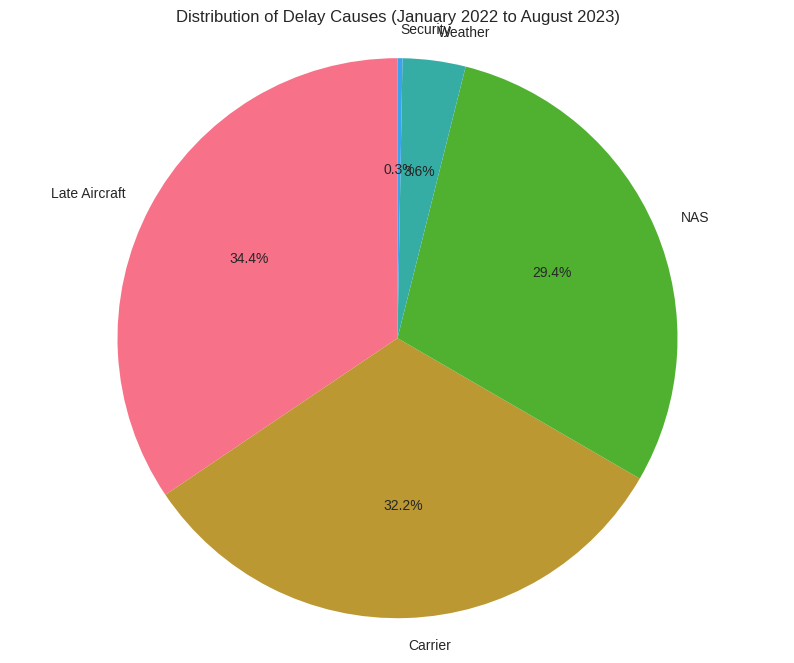

,Delayed flights,Share (%)
Late Aircraft,355965.59,34.45
Carrier,332676.21,32.19
NAS,304305.42,29.45
Weather,37503.04,3.63
Security,2943.97,0.28


In [ ]:
cause_columns = {
    "Carrier": "carrier_ct",
    "Weather": "weather_ct",
    "NAS": "nas_ct",
    "Security": "security_ct",
    "Late Aircraft": "late_aircraft_ct",
}

cause_totals = pd.Series(
    {label: df_filtered[column].sum() for label, column in cause_columns.items()}
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
plt.pie(
    cause_totals.values,
    labels=cause_totals.index,
    autopct="%1.1f%%",
    startangle=90,
)
plt.title(f"Distribution of Delay Causes ({analysis_period_label})")
plt.axis("equal")
plt.show()

cause_summary = pd.DataFrame(
    {
        "Delayed flights": cause_totals,
        "Share (%)": cause_totals / cause_totals.sum() * 100,
    }
)
display(cause_summary.round(2))

## Monthly patterns

Monthly rates are shown separately for each year. This avoids pooling a complete 2022 with an incomplete 2023.

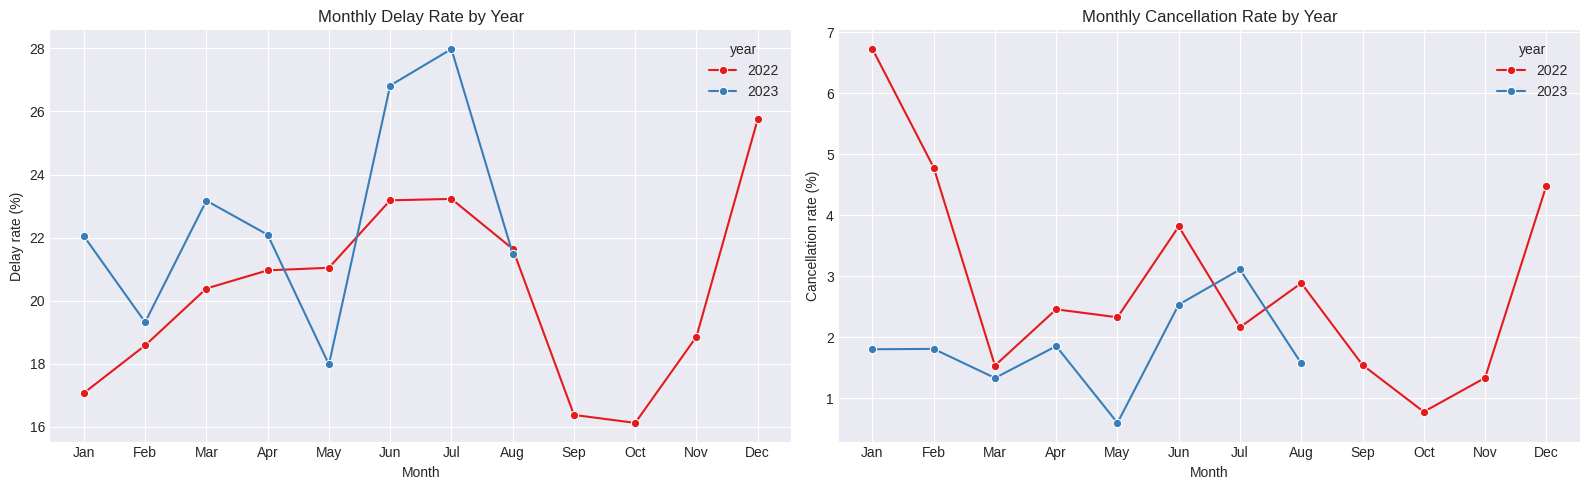

2022: highest delay rate in Dec (25.76%)
2022: highest cancellation rate in Jan (6.73%)
2023: highest delay rate in Jul (27.98%)
2023: highest cancellation rate in Jul (3.11%)


In [ ]:
monthly = (
    df_filtered.groupby(["year", "month"], as_index=False)
    .agg(
        arr_flights=("arr_flights", "sum"),
        arr_del15=("arr_del15", "sum"),
        arr_cancelled=("arr_cancelled", "sum"),
    )
)

monthly["delay_rate"] = monthly["arr_del15"] / monthly["arr_flights"] * 100
monthly["cancellation_rate"] = monthly["arr_cancelled"] / monthly["arr_flights"] * 100

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(
    data=monthly,
    x="month",
    y="delay_rate",
    hue="year",
    marker="o",
    palette="Set1",
    ax=axes[0],
)
axes[0].set_title("Monthly Delay Rate by Year")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Delay rate (%)")
axes[0].set_xticks(range(1, 13), month_labels)

sns.lineplot(
    data=monthly,
    x="month",
    y="cancellation_rate",
    hue="year",
    marker="o",
    palette="Set1",
    ax=axes[1],
)
axes[1].set_title("Monthly Cancellation Rate by Year")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Cancellation rate (%)")
axes[1].set_xticks(range(1, 13), month_labels)

plt.tight_layout()
plt.show()

for year, year_data in monthly.groupby("year"):
    peak_delay = year_data.loc[year_data["delay_rate"].idxmax()]
    peak_cancellation = year_data.loc[year_data["cancellation_rate"].idxmax()]
    print(
        f"{year}: highest delay rate in {month_labels[int(peak_delay['month']) - 1]} "
        f"({peak_delay['delay_rate']:.2f}%)"
    )
    print(
        f"{year}: highest cancellation rate in "
        f"{month_labels[int(peak_cancellation['month']) - 1]} "
        f"({peak_cancellation['cancellation_rate']:.2f}%)"
    )

## Performance by carrier

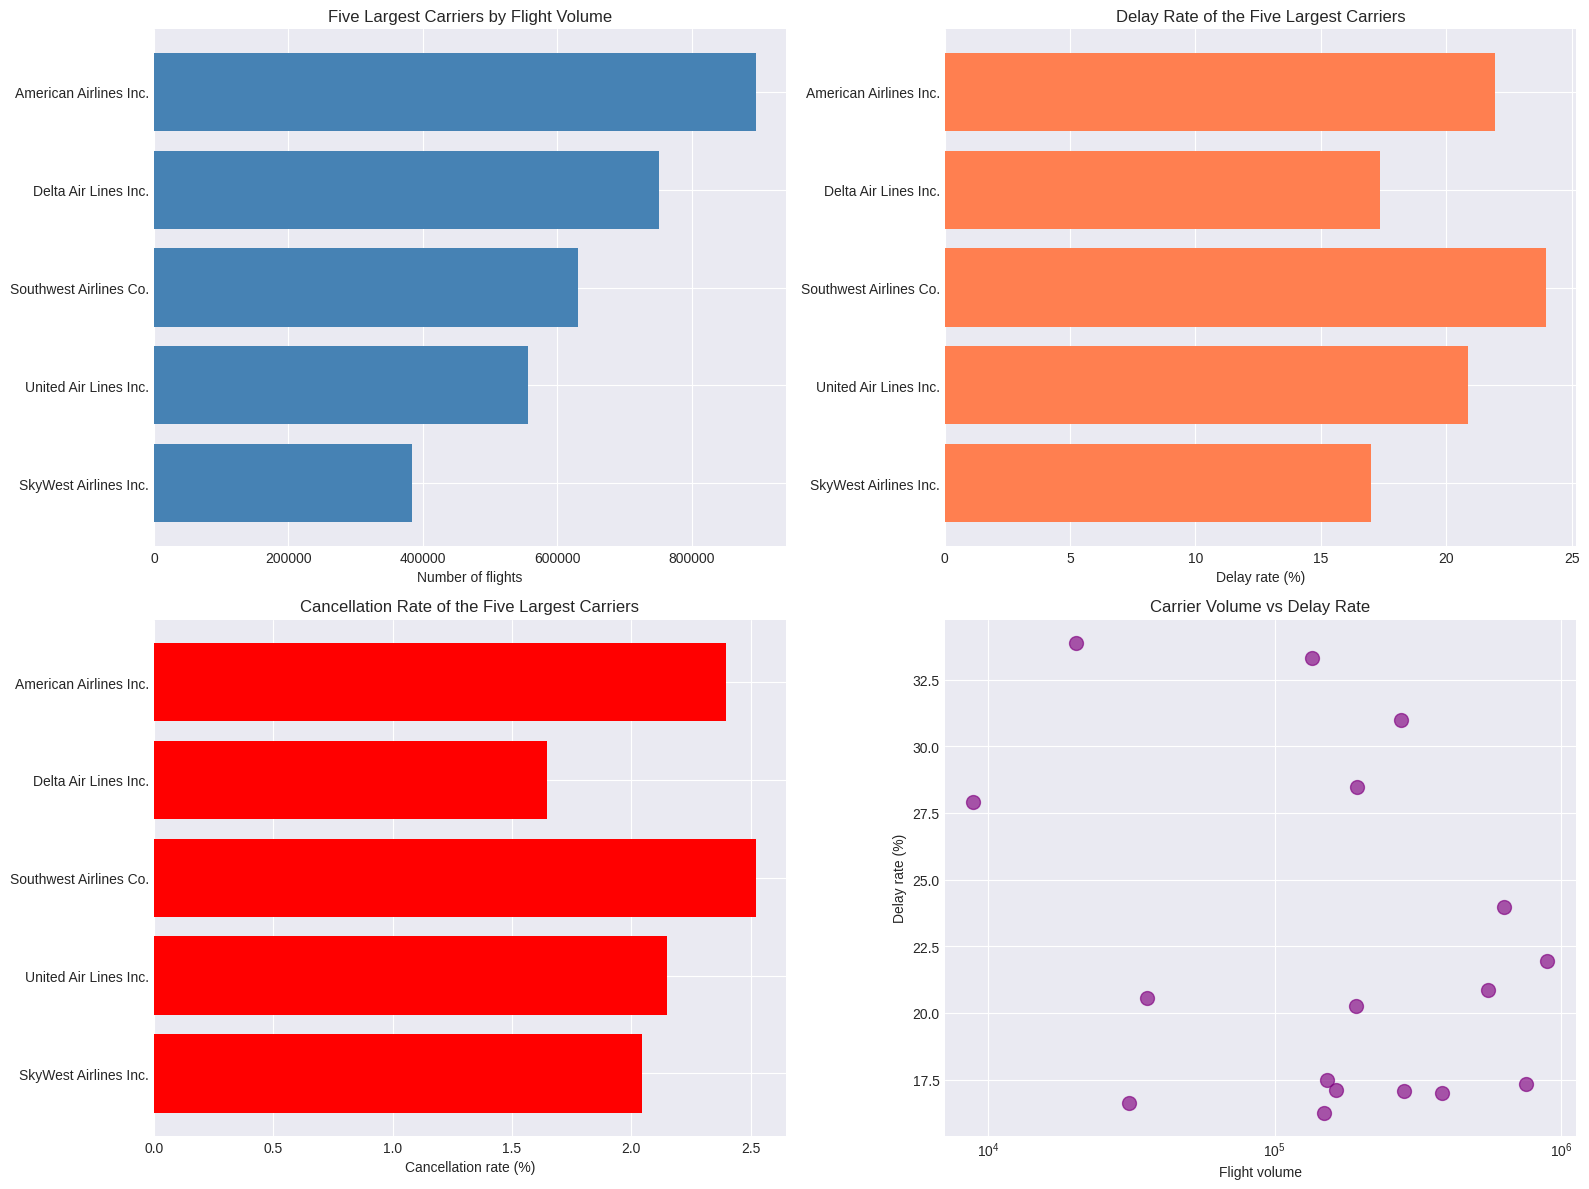

Lowest delay rates:


,carrier_name,delay_rate,arr_flights
4,Endeavor Air Inc.,16.267381,148223.0
8,Horizon Air,16.607149,31083.0
13,SkyWest Airlines Inc.,17.014370,384140.0


Highest delay rates:


,carrier_name,delay_rate,arr_flights
1,Allegiant Air,33.868339,20249.0
6,Frontier Airlines Inc.,33.293332,134997.0
9,JetBlue Airways,30.990400,276050.0


In [ ]:
carrier_performance = (
    df_filtered.groupby("carrier_name", as_index=False)
    .agg(
        arr_flights=("arr_flights", "sum"),
        arr_del15=("arr_del15", "sum"),
        arr_cancelled=("arr_cancelled", "sum"),
        arr_diverted=("arr_diverted", "sum"),
    )
)

carrier_performance["delay_rate"] = (
    carrier_performance["arr_del15"] / carrier_performance["arr_flights"] * 100
)
carrier_performance["cancellation_rate"] = (
    carrier_performance["arr_cancelled"] / carrier_performance["arr_flights"] * 100
)
carrier_performance["diversion_rate"] = (
    carrier_performance["arr_diverted"] / carrier_performance["arr_flights"] * 100
)

carrier_performance = carrier_performance.sort_values("arr_flights", ascending=False)
five_largest_carriers = carrier_performance.head(5)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].barh(
    five_largest_carriers["carrier_name"],
    five_largest_carriers["arr_flights"],
    color="steelblue",
)
axes[0, 0].set_xlabel("Number of flights")
axes[0, 0].set_title("Five Largest Carriers by Flight Volume")
axes[0, 0].invert_yaxis()

axes[0, 1].barh(
    five_largest_carriers["carrier_name"],
    five_largest_carriers["delay_rate"],
    color="coral",
)
axes[0, 1].set_xlabel("Delay rate (%)")
axes[0, 1].set_title("Delay Rate of the Five Largest Carriers")
axes[0, 1].invert_yaxis()

axes[1, 0].barh(
    five_largest_carriers["carrier_name"],
    five_largest_carriers["cancellation_rate"],
    color="red",
)
axes[1, 0].set_xlabel("Cancellation rate (%)")
axes[1, 0].set_title("Cancellation Rate of the Five Largest Carriers")
axes[1, 0].invert_yaxis()

axes[1, 1].scatter(
    carrier_performance["arr_flights"],
    carrier_performance["delay_rate"],
    s=100,
    alpha=0.65,
    color="purple",
)
axes[1, 1].set_xlabel("Flight volume")
axes[1, 1].set_ylabel("Delay rate (%)")
axes[1, 1].set_title("Carrier Volume vs Delay Rate")
axes[1, 1].set_xscale("log")

plt.tight_layout()
plt.show()

print("Lowest delay rates:")
display(carrier_performance.nsmallest(3, "delay_rate")[["carrier_name", "delay_rate", "arr_flights"]])

print("Highest delay rates:")
display(carrier_performance.nlargest(3, "delay_rate")[["carrier_name", "delay_rate", "arr_flights"]])

## Delay causes by carrier

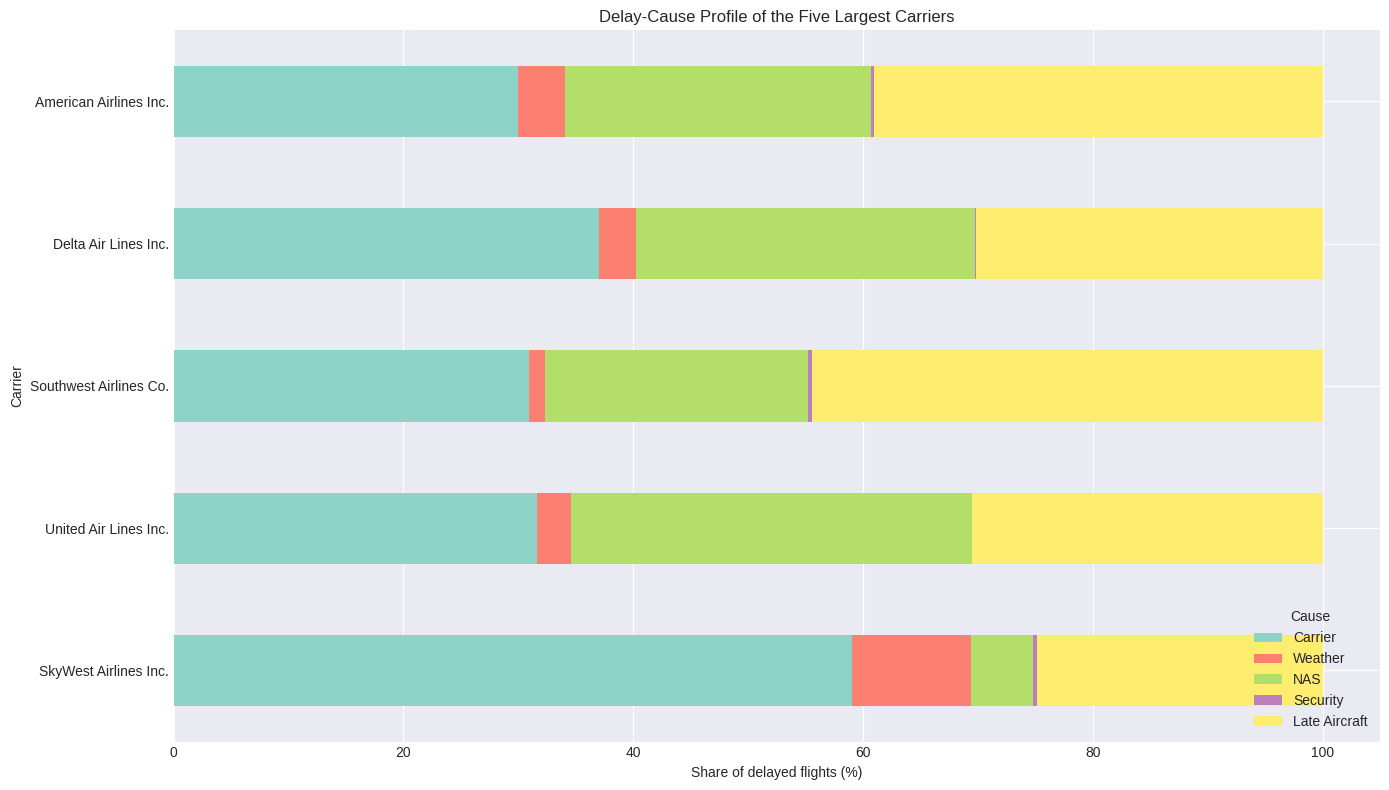

In [ ]:
cause_count_columns = list(cause_columns.values())

carrier_causes = (
    df_filtered.groupby("carrier_name", as_index=False)
    .agg({**{column: "sum" for column in cause_count_columns}, "arr_flights": "sum"})
)

total_cause_counts = carrier_causes[cause_count_columns].sum(axis=1).replace(0, np.nan)

for label, column in cause_columns.items():
    carrier_causes[f"{label}_share"] = carrier_causes[column] / total_cause_counts * 100

five_largest = carrier_causes.nlargest(5, "arr_flights").copy()
share_columns = [f"{label}_share" for label in cause_columns]
share_labels = list(cause_columns.keys())

ax = five_largest.set_index("carrier_name")[share_columns].plot(
    kind="barh",
    stacked=True,
    figsize=(14, 8),
    colormap="Set3",
)
ax.set_xlabel("Share of delayed flights (%)")
ax.set_ylabel("Carrier")
ax.set_title("Delay-Cause Profile of the Five Largest Carriers")
ax.legend(share_labels, title="Cause", loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Performance by airport

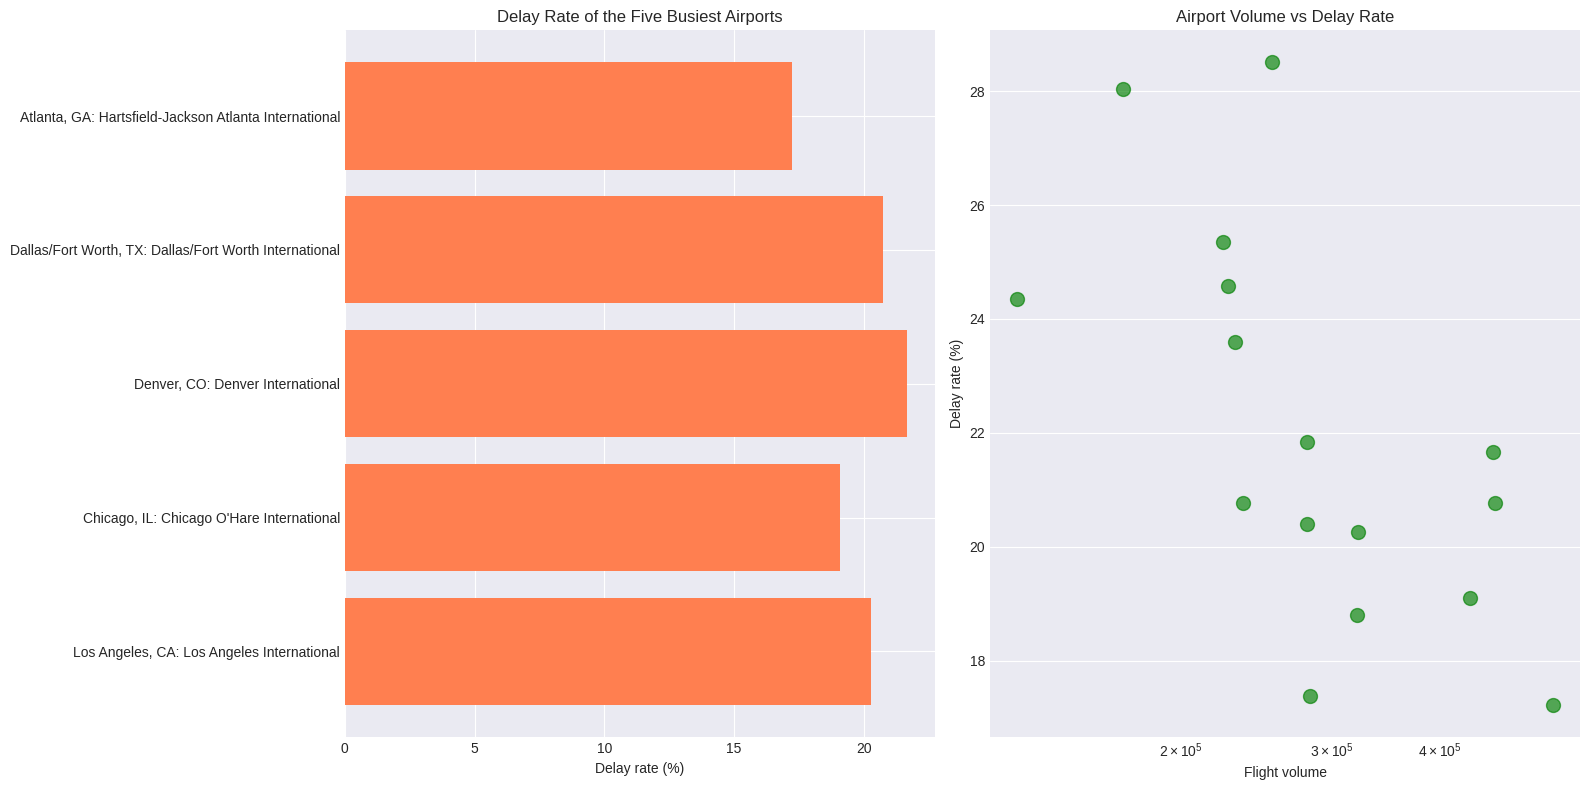

Lowest delay rates among the selected airports:


,airport_name,delay_rate,arr_flights
0,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",17.219750,541239.0
14,"Seattle, WA: Seattle/Tacoma International",17.379642,282595.0
2,"Charlotte, NC: Charlotte Douglas International",18.803872,320434.0


Highest delay rates among the selected airports:


,airport_name,delay_rate,arr_flights
12,"Orlando, FL: Orlando International",28.504055,255504.0
6,"Las Vegas, NV: Harry Reid International",28.031451,171568.0
11,"Newark, NJ: Newark Liberty International",25.352566,223930.0


In [ ]:
airport_performance = (
    df_filtered.groupby("airport_name", as_index=False)
    .agg(
        arr_flights=("arr_flights", "sum"),
        arr_del15=("arr_del15", "sum"),
        arr_cancelled=("arr_cancelled", "sum"),
    )
)

airport_performance["delay_rate"] = (
    airport_performance["arr_del15"] / airport_performance["arr_flights"] * 100
)
airport_performance["cancellation_rate"] = (
    airport_performance["arr_cancelled"] / airport_performance["arr_flights"] * 100
)

five_largest_airports = airport_performance.nlargest(5, "arr_flights")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(
    five_largest_airports["airport_name"],
    five_largest_airports["delay_rate"],
    color="coral",
)
axes[0].set_xlabel("Delay rate (%)")
axes[0].set_title("Delay Rate of the Five Busiest Airports")
axes[0].invert_yaxis()

axes[1].scatter(
    airport_performance["arr_flights"],
    airport_performance["delay_rate"],
    s=100,
    alpha=0.65,
    color="green",
)
axes[1].set_xlabel("Flight volume")
axes[1].set_ylabel("Delay rate (%)")
axes[1].set_title("Airport Volume vs Delay Rate")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

print("Lowest delay rates among the selected airports:")
display(airport_performance.nsmallest(3, "delay_rate")[["airport_name", "delay_rate", "arr_flights"]])

print("Highest delay rates among the selected airports:")
display(airport_performance.nlargest(3, "delay_rate")[["airport_name", "delay_rate", "arr_flights"]])

## Correlation analysis

Rates and cause shares are used instead of only raw counts. Raw operational counts are strongly affected by flight volume and can therefore produce misleadingly high correlations.

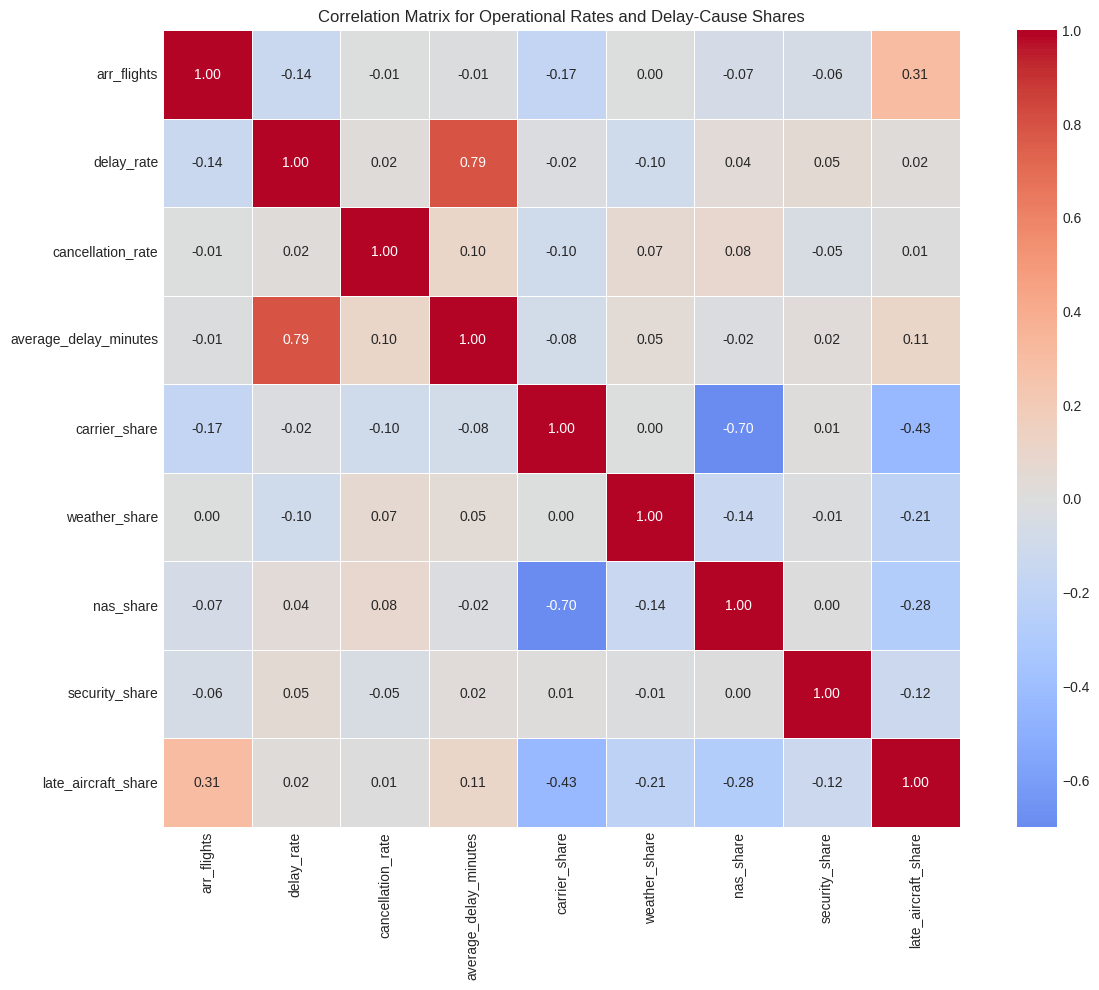

In [ ]:
correlation_data = eda_metrics.copy()
delayed_denominator = correlation_data["arr_del15"].replace(0, np.nan)

correlation_data["carrier_share"] = correlation_data["carrier_ct"] / delayed_denominator * 100
correlation_data["weather_share"] = correlation_data["weather_ct"] / delayed_denominator * 100
correlation_data["nas_share"] = correlation_data["nas_ct"] / delayed_denominator * 100
correlation_data["security_share"] = correlation_data["security_ct"] / delayed_denominator * 100
correlation_data["late_aircraft_share"] = correlation_data["late_aircraft_ct"] / delayed_denominator * 100

correlation_columns = [
    "arr_flights",
    "delay_rate",
    "cancellation_rate",
    "average_delay_minutes",
    "carrier_share",
    "weather_share",
    "nas_share",
    "security_share",
    "late_aircraft_share",
]

correlation_matrix = correlation_data[correlation_columns].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Correlation Matrix for Operational Rates and Delay-Cause Shares")
plt.tight_layout()
plt.show()

## Outlier exploration

Outliers are identified for diagnostic purposes only. They are retained for clustering because extreme delay and cancellation events are operationally meaningful.

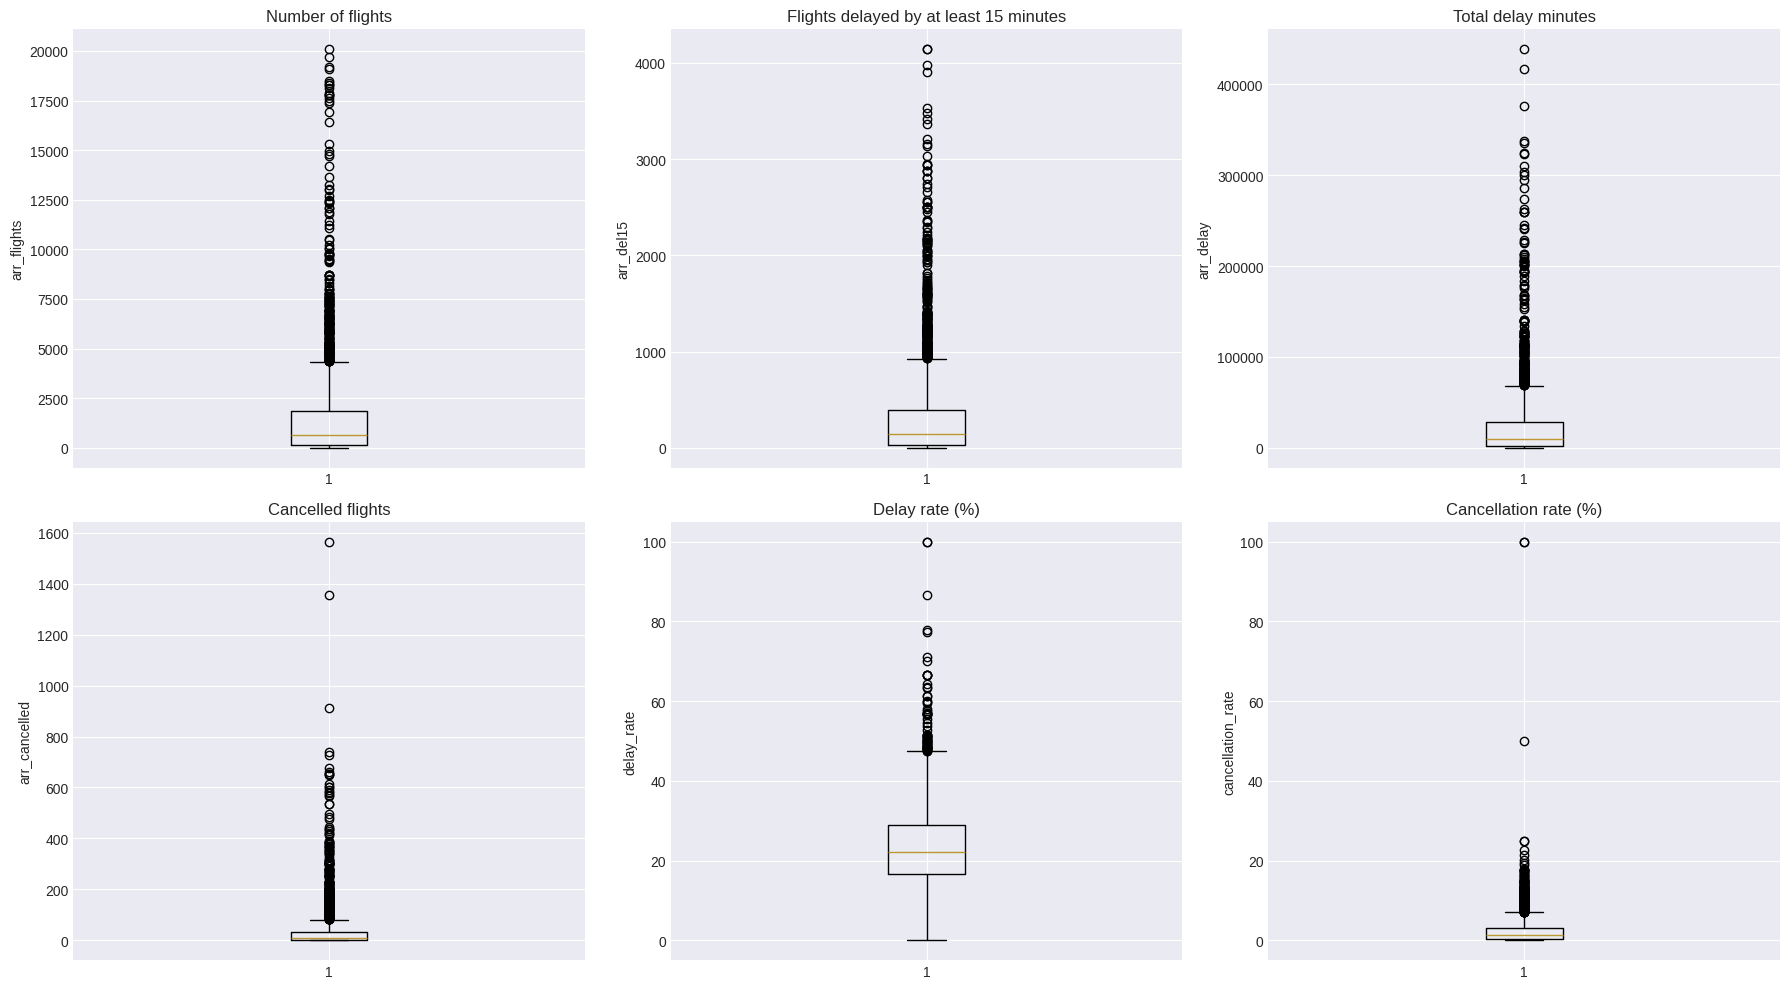

,variable,lower_bound,upper_bound,outlier_count,outlier_share_%
0,arr_flights,-4886.25,6865.00,102,3.01
1,arr_del15,-1038.75,1462.00,99,2.93
2,arr_delay,-77909.75,108493.25,106,3.13
3,arr_cancelled,-95.00,129.00,225,6.65
4,delay_rate,-20.43,66.13,11,0.33
5,cancellation_rate,-7.53,11.04,95,2.81


In [ ]:
outlier_variables = {
    "arr_flights": "Number of flights",
    "arr_del15": "Flights delayed by at least 15 minutes",
    "arr_delay": "Total delay minutes",
    "arr_cancelled": "Cancelled flights",
    "delay_rate": "Delay rate (%)",
    "cancellation_rate": "Cancellation rate (%)",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (column, title) in zip(axes.flatten(), outlier_variables.items()):
    values = eda_metrics[column].dropna()
    ax.boxplot(values, vert=True)
    ax.set_ylabel(column)
    ax.set_title(title)

plt.tight_layout()
plt.show()

outlier_summary = []
for column in outlier_variables:
    values = eda_metrics[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr
    outlier_count = ((values < lower_bound) | (values > upper_bound)).sum()

    outlier_summary.append(
        {
            "variable": column,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_count,
            "outlier_share_%": outlier_count / len(values) * 100,
        }
    )

display(pd.DataFrame(outlier_summary).round(2))

## Data-consistency checks

In [ ]:
count_columns = [
    "arr_flights", "arr_del15", "carrier_ct", "weather_ct", "nas_ct",
    "security_ct", "late_aircraft_ct", "arr_cancelled", "arr_diverted"
]

negative_value_count = (df_filtered[count_columns] < 0).sum().sum()
delayed_above_flights = (df_filtered["arr_del15"] > df_filtered["arr_flights"]).sum()
cancelled_above_flights = (df_filtered["arr_cancelled"] > df_filtered["arr_flights"]).sum()

delay_cause_columns = list(cause_columns.values())
delay_cause_sum = df_filtered[delay_cause_columns].sum(axis=1)
cause_difference = (delay_cause_sum - df_filtered["arr_del15"]).abs()
cause_tolerance = np.maximum(0.5, df_filtered["arr_del15"] * 0.01)
inconsistent_cause_rows = (cause_difference > cause_tolerance).sum()

minute_columns = [
    "carrier_delay", "weather_delay", "nas_delay",
    "security_delay", "late_aircraft_delay"
]
delay_minute_sum = df_filtered[minute_columns].sum(axis=1)
inconsistent_minute_rows = ((delay_minute_sum - df_filtered["arr_delay"]).abs() > 1).sum()

consistency_results = pd.Series(
    {
        "Negative count values": negative_value_count,
        "Delayed flights above total flights": delayed_above_flights,
        "Cancelled flights above total flights": cancelled_above_flights,
        "Rows with inconsistent delay-cause totals": inconsistent_cause_rows,
        "Rows with inconsistent delay-minute totals": inconsistent_minute_rows,
    },
    name="Number of affected rows",
)

display(consistency_results.to_frame())

,Number of affected rows
Negative count values,0
Delayed flights above total flights,0
Cancelled flights above total flights,0
Rows with inconsistent delay-cause totals,0
Rows with inconsistent delay-minute totals,0


## EDA summary

In [ ]:
print("DATASET")
print(f"  Period: {analysis_period_label}")
print(f"  Records: {len(df_filtered):,}")
print(f"  Carriers: {df_filtered['carrier'].nunique()}")
print(f"  Airports: {df_filtered['airport'].nunique()}")
print(f"  Total flight volume: {total_flights:,.0f}")

print("\nOPERATIONAL PERFORMANCE")
print(f"  Overall delay rate: {overall_delay_rate:.2f}%")
print(f"  Overall cancellation rate: {overall_cancellation_rate:.2f}%")
print(f"  Average delay minutes per scheduled flight: {average_delay_minutes:.2f}")

print("\nDELAY CAUSES")
for cause, value in cause_totals.items():
    print(f"  {cause}: {value / cause_totals.sum() * 100:.1f}%")

# Fair year-to-year comparison using only months available in both years
common_months = sorted(
    set(monthly.loc[monthly["year"] == 2022, "month"])
    & set(monthly.loc[monthly["year"] == 2023, "month"])
)

comparable_period = monthly.loc[monthly["month"].isin(common_months)]
yearly_comparison = (
    comparable_period.groupby("year", as_index=False)
    .agg(arr_flights=("arr_flights", "sum"), arr_del15=("arr_del15", "sum"))
)
yearly_comparison["delay_rate"] = (
    yearly_comparison["arr_del15"] / yearly_comparison["arr_flights"] * 100
)

print(f"\nYEAR-TO-YEAR COMPARISON (months 1-{max(common_months)})")
for row in yearly_comparison.itertuples():
    print(f"  {row.year}: {row.delay_rate:.2f}% delay rate")

DATASET
  Period: January 2022 to August 2023
  Records: 3,384
  Carriers: 17
  Airports: 15
  Total flight volume: 4,858,458

OPERATIONAL PERFORMANCE
  Overall delay rate: 21.27%
  Overall cancellation rate: 2.44%
  Average delay minutes per scheduled flight: 15.79

DELAY CAUSES
  Late Aircraft: 34.4%
  Carrier: 32.2%
  NAS: 29.4%
  Weather: 3.6%
  Security: 0.3%

YEAR-TO-YEAR COMPARISON (months 1-8)
  2022: 20.84% delay rate
  2023: 22.68% delay rate


# Feature engineering for clustering

Clustering focuses on operational behaviour rather than identity. Carrier and airport codes are therefore retained for profiling after clustering but are not included in the Euclidean-distance calculation.

Security-related delays are reported in the EDA but excluded from clustering because they represent a very small proportion of delays and rare values could receive excessive weight after standardisation.

In [ ]:
df_features = df_filtered.copy().reset_index(drop=True)
assert df_features.isna().sum().sum() == 0, "Missing values remain in the dataset."

safe_flights = df_features["arr_flights"].replace(0, np.nan)
safe_delayed = df_features["arr_del15"].replace(0, np.nan)

df_features["delay_rate"] = df_features["arr_del15"] / safe_flights * 100
df_features["cancellation_rate"] = df_features["arr_cancelled"] / safe_flights * 100
df_features["carrier_delay_share"] = df_features["carrier_ct"] / safe_delayed * 100
df_features["weather_delay_share"] = df_features["weather_ct"] / safe_delayed * 100
df_features["nas_delay_share"] = df_features["nas_ct"] / safe_delayed * 100
df_features["late_aircraft_delay_share"] = df_features["late_aircraft_ct"] / safe_delayed * 100

feature_columns = [
    "delay_rate",
    "cancellation_rate",
    "carrier_delay_share",
    "weather_delay_share",
    "nas_delay_share",
    "late_aircraft_delay_share",
]

df_features[feature_columns] = df_features[feature_columns].fillna(0)

print("Features selected for clustering:")
for feature in feature_columns:
    print(f"  - {feature}")

display(df_features[feature_columns].describe().T)

Features selected for clustering:
  - delay_rate
  - cancellation_rate
  - carrier_delay_share
  - weather_delay_share
  - nas_delay_share
  - late_aircraft_delay_share


,count,mean,std,min,25%,50%,75%,max
delay_rate,3384.0,23.451561,10.075462,0.0,16.666667,22.136814,29.032258,100.0
cancellation_rate,3384.0,2.487314,3.952620,0.0,0.429185,1.405152,3.081352,100.0
carrier_delay_share,3384.0,37.473178,17.835055,0.0,26.239878,33.682010,44.542460,100.0
weather_delay_share,3384.0,3.771063,5.274914,0.0,0.773038,2.470740,4.643110,100.0
nas_delay_share,3384.0,30.123526,16.957166,0.0,19.712533,29.868691,40.791617,100.0
late_aircraft_delay_share,3384.0,27.289663,13.712765,0.0,18.531579,27.730384,36.733780,100.0


## Standardisation

In [ ]:
scaler = StandardScaler()
X_clustering = scaler.fit_transform(df_features[feature_columns])

if not np.isfinite(X_clustering).all():
    raise ValueError("The clustering matrix contains non-finite values.")

print(f"Clustering matrix shape: {X_clustering.shape}")
print("Extreme observations are retained because they are operationally meaningful.")

Clustering matrix shape: (3384, 6)
Extreme observations are retained because they are operationally meaningful.


# K-Means clustering

## Select the number of clusters

Candidate values are compared using inertia, silhouette score, and Davies-Bouldin score. The automatic selection uses the highest silhouette score; the other metrics and business interpretability should also be considered.

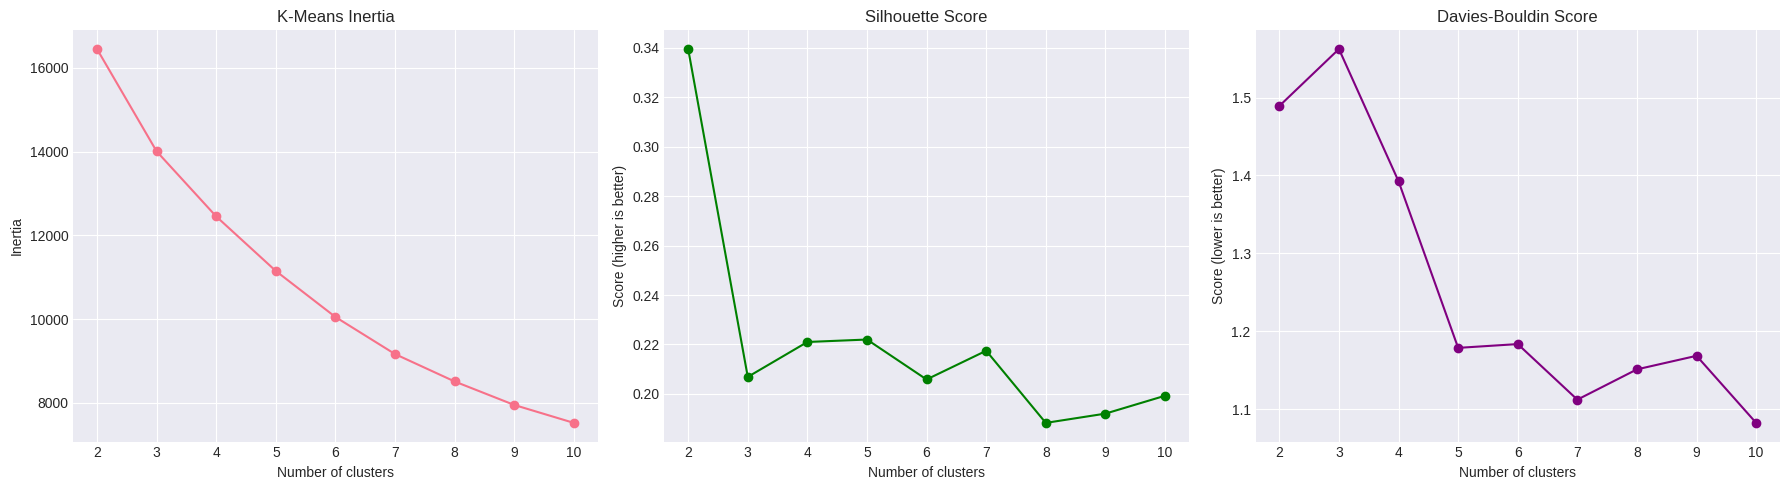

,k,inertia,silhouette,davies_bouldin
0,2,16449.020,0.340,1.489
1,3,14005.566,0.207,1.562
2,4,12449.955,0.221,1.393
3,5,11147.635,0.222,1.179
4,6,10048.496,0.206,1.184
5,7,9162.517,0.217,1.112
6,8,8508.188,0.188,1.151
7,9,7947.078,0.192,1.169
8,10,7518.637,0.199,1.082


Selected K-Means k based on silhouette score: 2


In [ ]:
k_values = range(2, 11)
kmeans_selection_rows = []

for k in k_values:
    candidate = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = candidate.fit_predict(X_clustering)

    kmeans_selection_rows.append(
        {
            "k": k,
            "inertia": candidate.inertia_,
            "silhouette": silhouette_score(X_clustering, labels),
            "davies_bouldin": davies_bouldin_score(X_clustering, labels),
        }
    )

kmeans_selection = pd.DataFrame(kmeans_selection_rows)
k_opt = int(
    kmeans_selection.loc[kmeans_selection["silhouette"].idxmax(), "k"]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(kmeans_selection["k"], kmeans_selection["inertia"], marker="o")
axes[0].set_title("K-Means Inertia")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")

axes[1].plot(kmeans_selection["k"], kmeans_selection["silhouette"], marker="o", color="green")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Score (higher is better)")

axes[2].plot(kmeans_selection["k"], kmeans_selection["davies_bouldin"], marker="o", color="purple")
axes[2].set_title("Davies-Bouldin Score")
axes[2].set_xlabel("Number of clusters")
axes[2].set_ylabel("Score (lower is better)")

plt.tight_layout()
plt.show()

display(kmeans_selection.round(3))
print(f"Selected K-Means k based on silhouette score: {k_opt}")

## Final K-Means model and cluster profiles

K-Means silhouette score: 0.340
K-Means Davies-Bouldin score: 1.489


,size,delay_rate,cancellation_rate,carrier_delay_share,weather_delay_share,nas_delay_share,late_aircraft_delay_share,share_of_records_%,most_common_carrier,most_common_airport
kmeans_cluster,,,,,,,,,,
0,2788,23.66,2.64,31.13,3.10,34.39,29.88,82.39,American Airlines Inc.,ATL
1,596,22.50,1.79,67.15,6.91,10.17,15.19,17.61,SkyWest Airlines Inc.,SEA


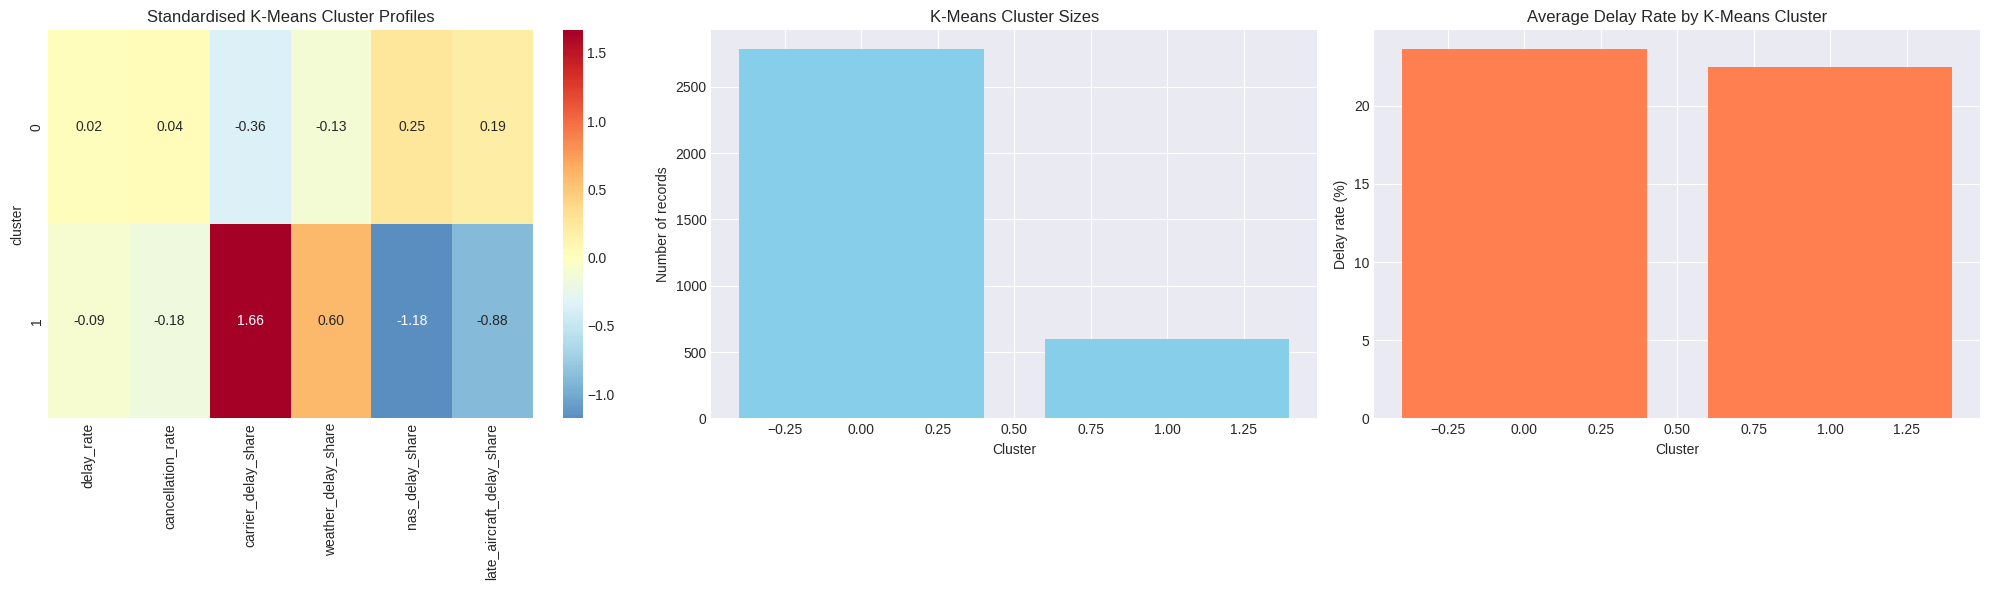

In [ ]:
kmeans_model = KMeans(
    n_clusters=k_opt,
    random_state=RANDOM_STATE,
    n_init=20,
)
kmeans_labels = kmeans_model.fit_predict(X_clustering)

kmeans_silhouette = silhouette_score(X_clustering, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_clustering, kmeans_labels)

df_clustered = df_features.copy()
df_clustered["kmeans_cluster"] = kmeans_labels

kmeans_profile = df_clustered.groupby("kmeans_cluster")[feature_columns].mean()
kmeans_profile.insert(0, "size", df_clustered["kmeans_cluster"].value_counts().sort_index())
kmeans_profile["share_of_records_%"] = kmeans_profile["size"] / len(df_clustered) * 100

top_carrier_by_cluster = df_clustered.groupby("kmeans_cluster")["carrier_name"].agg(
    lambda values: values.value_counts().index[0]
)
top_airport_by_cluster = df_clustered.groupby("kmeans_cluster")["airport"].agg(
    lambda values: values.value_counts().index[0]
)
kmeans_profile["most_common_carrier"] = top_carrier_by_cluster
kmeans_profile["most_common_airport"] = top_airport_by_cluster

print(f"K-Means silhouette score: {kmeans_silhouette:.3f}")
print(f"K-Means Davies-Bouldin score: {kmeans_davies_bouldin:.3f}")
display(kmeans_profile.round(2))

standardised_kmeans_profile = (
    pd.DataFrame(X_clustering, columns=feature_columns)
    .assign(cluster=kmeans_labels)
    .groupby("cluster")[feature_columns]
    .mean()
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(
    standardised_kmeans_profile,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    ax=axes[0],
)
axes[0].set_title("Standardised K-Means Cluster Profiles")

cluster_sizes = np.bincount(kmeans_labels)
axes[1].bar(range(k_opt), cluster_sizes, color="skyblue")
axes[1].set_title("K-Means Cluster Sizes")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Number of records")

delay_rates = kmeans_profile["delay_rate"]
axes[2].bar(delay_rates.index, delay_rates.values, color="coral")
axes[2].set_title("Average Delay Rate by K-Means Cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Delay rate (%)")

plt.tight_layout()
plt.show()

### Interpreting the K-Means results

In the heatmap, positive values are above the dataset average and negative values are below it. Cluster labels are arbitrary and should be interpreted from their complete profiles rather than ranked as universally “best” or “worst”.

A low silhouette score indicates substantial overlap between operational profiles. In that case, the clusters remain useful for exploratory segmentation but should not be presented as sharply separated natural groups.

# Hierarchical clustering

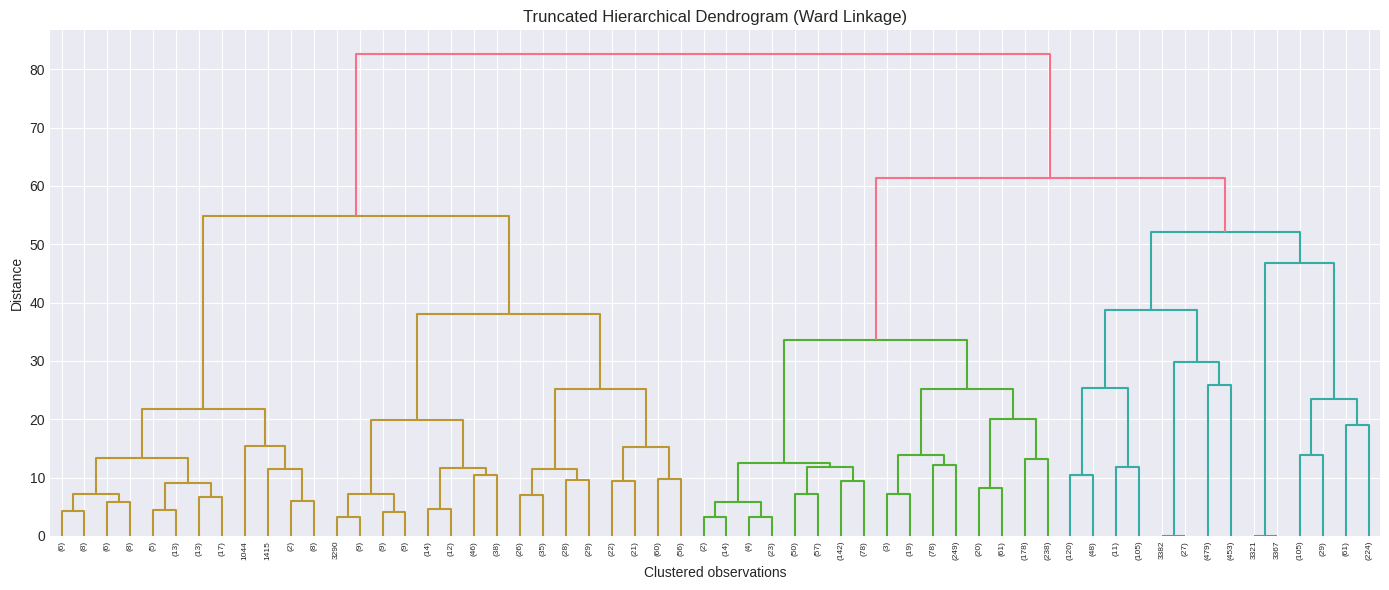

In [ ]:
linkage_matrix = linkage(X_clustering, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode="level", p=5)
plt.title("Truncated Hierarchical Dendrogram (Ward Linkage)")
plt.xlabel("Clustered observations")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## Select the number of hierarchical clusters

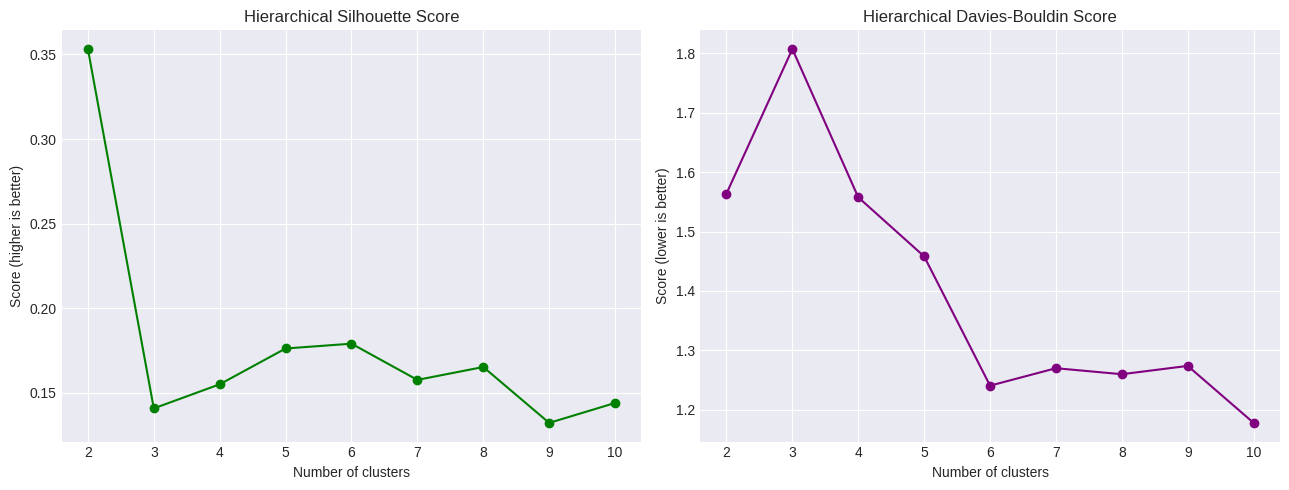

,k,silhouette,davies_bouldin
0,2,0.353,1.564
1,3,0.141,1.807
2,4,0.155,1.558
3,5,0.176,1.458
4,6,0.179,1.240
5,7,0.158,1.270
6,8,0.165,1.260
7,9,0.132,1.274
8,10,0.144,1.178


Selected hierarchical k based on silhouette score: 2


In [ ]:
hierarchical_selection_rows = []

for k in range(2, 11):
    labels = fcluster(linkage_matrix, t=k, criterion="maxclust") - 1
    hierarchical_selection_rows.append(
        {
            "k": k,
            "silhouette": silhouette_score(X_clustering, labels),
            "davies_bouldin": davies_bouldin_score(X_clustering, labels),
        }
    )

hierarchical_selection = pd.DataFrame(hierarchical_selection_rows)
hierarchical_k_opt = int(
    hierarchical_selection.loc[
        hierarchical_selection["silhouette"].idxmax(), "k"
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    hierarchical_selection["k"],
    hierarchical_selection["silhouette"],
    marker="o",
    color="green",
)
axes[0].set_title("Hierarchical Silhouette Score")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Score (higher is better)")

axes[1].plot(
    hierarchical_selection["k"],
    hierarchical_selection["davies_bouldin"],
    marker="o",
    color="purple",
)
axes[1].set_title("Hierarchical Davies-Bouldin Score")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Score (lower is better)")

plt.tight_layout()
plt.show()

display(hierarchical_selection.round(3))
print(f"Selected hierarchical k based on silhouette score: {hierarchical_k_opt}")

## Hierarchical cluster profiles

Hierarchical silhouette score: 0.353
Hierarchical Davies-Bouldin score: 1.564


,size,delay_rate,cancellation_rate,carrier_delay_share,weather_delay_share,nas_delay_share,late_aircraft_delay_share,share_of_records_%
hierarchical_cluster,,,,,,,,
0,503,25.60,1.50,67.13,7.86,9.34,15.10,14.86
1,2881,23.08,2.66,32.30,3.06,33.75,29.42,85.14


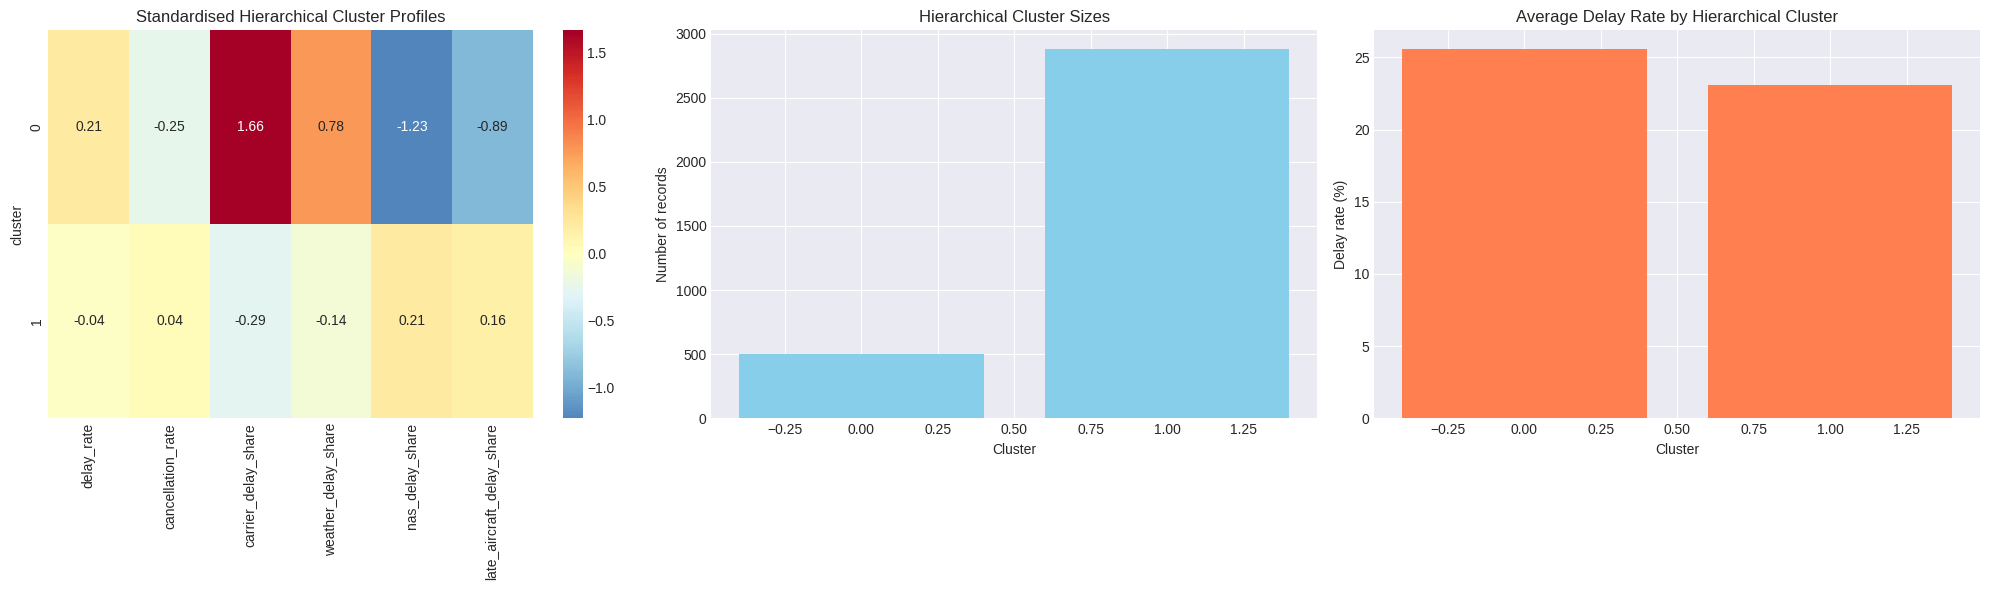

In [ ]:
hierarchical_labels = (
    fcluster(linkage_matrix, t=hierarchical_k_opt, criterion="maxclust") - 1
)

hierarchical_silhouette = silhouette_score(X_clustering, hierarchical_labels)
hierarchical_davies_bouldin = davies_bouldin_score(
    X_clustering, hierarchical_labels
)

df_clustered["hierarchical_cluster"] = hierarchical_labels

hierarchical_profile = (
    df_clustered.groupby("hierarchical_cluster")[feature_columns].mean()
)
hierarchical_profile.insert(
    0,
    "size",
    df_clustered["hierarchical_cluster"].value_counts().sort_index(),
)
hierarchical_profile["share_of_records_%"] = (
    hierarchical_profile["size"] / len(df_clustered) * 100
)

print(f"Hierarchical silhouette score: {hierarchical_silhouette:.3f}")
print(f"Hierarchical Davies-Bouldin score: {hierarchical_davies_bouldin:.3f}")
display(hierarchical_profile.round(2))

standardised_hierarchical_profile = (
    pd.DataFrame(X_clustering, columns=feature_columns)
    .assign(cluster=hierarchical_labels)
    .groupby("cluster")[feature_columns]
    .mean()
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(
    standardised_hierarchical_profile,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    ax=axes[0],
)
axes[0].set_title("Standardised Hierarchical Cluster Profiles")

hierarchical_sizes = np.bincount(hierarchical_labels)
axes[1].bar(range(hierarchical_k_opt), hierarchical_sizes, color="skyblue")
axes[1].set_title("Hierarchical Cluster Sizes")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Number of records")

hierarchical_delay_rates = hierarchical_profile["delay_rate"]
axes[2].bar(
    hierarchical_delay_rates.index,
    hierarchical_delay_rates.values,
    color="coral",
)
axes[2].set_title("Average Delay Rate by Hierarchical Cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Delay rate (%)")

plt.tight_layout()
plt.show()

# PCA visualisation and model comparison

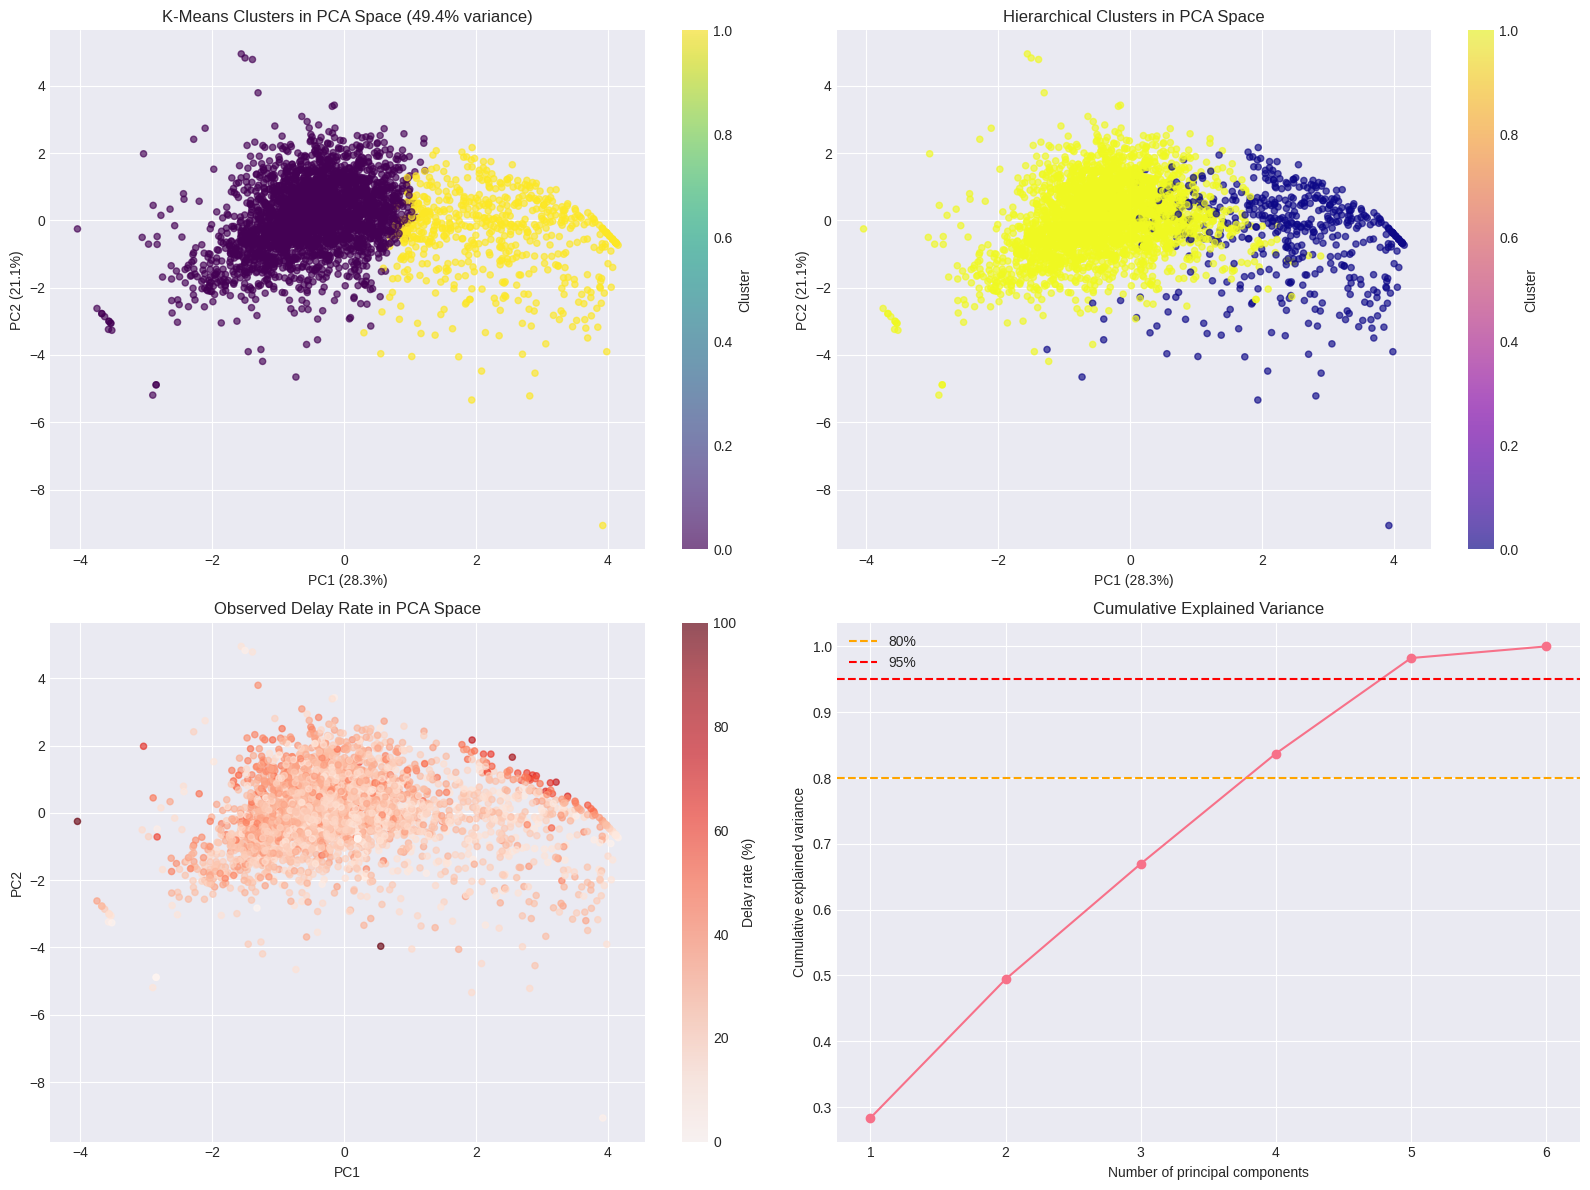

,method,clusters,silhouette,davies_bouldin
0,K-Means,2,0.340,1.489
1,Hierarchical (Ward),2,0.353,1.564


Higher silhouette score in this comparison: Hierarchical (Ward)
Variance represented by the two-dimensional PCA projection: 49.4%


In [ ]:
pca_2d_model = PCA(n_components=2)
X_pca_2d = pca_2d_model.fit_transform(X_clustering)
explained_2d = pca_2d_model.explained_variance_ratio_.sum() * 100

pca_full = PCA().fit(X_clustering)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

scatter_kmeans = axes[0, 0].scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    alpha=0.65,
    s=20,
)
axes[0, 0].set_title(f"K-Means Clusters in PCA Space ({explained_2d:.1f}% variance)")
axes[0, 0].set_xlabel(f"PC1 ({pca_2d_model.explained_variance_ratio_[0]:.1%})")
axes[0, 0].set_ylabel(f"PC2 ({pca_2d_model.explained_variance_ratio_[1]:.1%})")
fig.colorbar(scatter_kmeans, ax=axes[0, 0], label="Cluster")

scatter_hierarchical = axes[0, 1].scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=hierarchical_labels,
    cmap="plasma",
    alpha=0.65,
    s=20,
)
axes[0, 1].set_title("Hierarchical Clusters in PCA Space")
axes[0, 1].set_xlabel(f"PC1 ({pca_2d_model.explained_variance_ratio_[0]:.1%})")
axes[0, 1].set_ylabel(f"PC2 ({pca_2d_model.explained_variance_ratio_[1]:.1%})")
fig.colorbar(scatter_hierarchical, ax=axes[0, 1], label="Cluster")

scatter_delay = axes[1, 0].scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=df_features["delay_rate"],
    cmap="Reds",
    alpha=0.65,
    s=20,
)
axes[1, 0].set_title("Observed Delay Rate in PCA Space")
axes[1, 0].set_xlabel("PC1")
axes[1, 0].set_ylabel("PC2")
fig.colorbar(scatter_delay, ax=axes[1, 0], label="Delay rate (%)")

axes[1, 1].plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
)
axes[1, 1].axhline(0.80, color="orange", linestyle="--", label="80%")
axes[1, 1].axhline(0.95, color="red", linestyle="--", label="95%")
axes[1, 1].set_title("Cumulative Explained Variance")
axes[1, 1].set_xlabel("Number of principal components")
axes[1, 1].set_ylabel("Cumulative explained variance")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

clustering_comparison = pd.DataFrame(
    {
        "method": ["K-Means", "Hierarchical (Ward)"],
        "clusters": [k_opt, hierarchical_k_opt],
        "silhouette": [kmeans_silhouette, hierarchical_silhouette],
        "davies_bouldin": [kmeans_davies_bouldin, hierarchical_davies_bouldin],
    }
)

display(clustering_comparison.round(3))

best_method = clustering_comparison.loc[
    clustering_comparison["silhouette"].idxmax(), "method"
]
print(f"Higher silhouette score in this comparison: {best_method}")
print(f"Variance represented by the two-dimensional PCA projection: {explained_2d:.1f}%")

# Conclusion and limitations

This notebook combines descriptive analysis and unsupervised learning to identify recurring operational profiles in airline-delay records. Cluster interpretation should be based on the raw profile tables, standardised heatmaps, cluster sizes, and validation metrics together.

Important limitations:

- The dataset is aggregated by carrier, airport, year, and month; it does not contain individual flights.
- Data for 2023 ends in August, so full-year comparisons with 2022 are not appropriate.
- Clustering is exploratory and does not demonstrate that any feature causes delays.
- Cluster assignments depend on feature selection, scaling, distance assumptions, and the selected number of clusters.
- PCA provides a two-dimensional visualisation that does not preserve all information from the original feature space.